In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from features import (feature_total_pages_count,
                      total_number_of_sessions,
                      time_last_used,
                      generate_time_features,
                      last_level_of_each_customer,
                      device_used_by_user)

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

In [ ]:
full_dataset_df = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [19]:
full_dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17499636 entries, 0 to 25661583
Data columns (total 19 columns):
 #   Column         Dtype         
---  ------         -----         
 0   status         int64         
 1   gender         object        
 2   firstName      object        
 3   level          object        
 4   lastName       object        
 5   userId         object        
 6   ts             int64         
 7   auth           object        
 8   page           object        
 9   sessionId      int64         
 10  location       object        
 11  itemInSession  int64         
 12  userAgent      object        
 13  method         object        
 14  length         float64       
 15  song           object        
 16  artist         object        
 17  time           datetime64[us]
 18  registration   datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(4), object(12)
memory usage: 2.6+ GB


In [ ]:
df_train = full_dataset_df.copy()
df_test = full_dataset_df.copy()

In [79]:
# First Test set
#cutoff_train = pd.Timestamp("2018-10-08")
#cutoff_test = pd.Timestamp("2018-10-18")

# Second Train Test set
cutoff_train = pd.Timestamp("2018-10-15")
cutoff_test = pd.Timestamp("2018-10-25")

In [80]:
df_train = df_train[df_train["time"] <= cutoff_train]
#df_test = df_test[(df_test["time"] > cutoff_train) & (df_test["time"] <= cutoff_test)]
df_test = df_test[df_test["time"] <= cutoff_test]

In [81]:
def create_feature_engineered_df(df):
    page_features_df = feature_total_pages_count(df)
    tnos_features_df = total_number_of_sessions(df = df)
    time_last_used_df = time_last_used(df = df)
    generate_time_features_df = generate_time_features(df = df)
    last_level_of_each_customer_df = last_level_of_each_customer(df = df)
    device_used_by_user_df = device_used_by_user(df = df)

    page_features_df.reset_index(inplace=True)
    df = page_features_df.merge(tnos_features_df, how = "inner", on = "userId")
    df = df.merge(time_last_used_df, on = "userId")
    df = df.merge(generate_time_features_df, on = "userId")
    df = df.merge(last_level_of_each_customer_df, on = "userId")
    df = df.merge(device_used_by_user_df, on = "userId")

    df["mean_tbs_minutes"] = df["mean_tbs_minutes"].fillna(1000)
    df["median_tbs_minutes"] = df["median_tbs_minutes"].fillna(1000)

    return df

In [82]:
df_features_train = create_feature_engineered_df(df_train)
df_features_test = create_feature_engineered_df(df_test)

In [83]:
df_features_test

,userId,About,Add Friend,Add to Playlist,Cancel,Cancellation Confirmation,Downgrade,Error,Help,Home,...,Thumbs Up,Upgrade,total_number_of_sessions,time_not_used,mean_tps_minutes,mean_tbs_minutes,median_tps_minutes,median_tbs_minutes,level,exact_device
0,1000025,1.0,30.0,53.0,1.0,1.0,18.0,1.0,8.0,77.0,...,94.0,1.0,17,46286.0,404.0,1457.0,341.0,1078.0,1,Windows
1,1000035,2.0,9.0,11.0,0.0,0.0,1.0,0.0,3.0,21.0,...,39.0,5.0,10,39459.0,192.0,2850.0,131.0,2130.0,1,Linux
2,1000083,0.0,6.0,8.0,1.0,1.0,2.0,0.0,2.0,21.0,...,21.0,3.0,11,55555.0,186.0,1557.0,121.0,784.0,1,Windows
3,1000103,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,1.0,1,66466.0,162.0,1000.0,162.0,1000.0,1,Linux
4,1000164,1.0,5.0,10.0,0.0,0.0,0.0,0.0,2.0,14.0,...,14.0,1.0,9,45370.0,151.0,3167.0,26.0,1940.0,1,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17883,1999781,2.0,10.0,19.0,0.0,0.0,0.0,0.0,3.0,32.0,...,18.0,3.0,17,38224.0,140.0,2088.0,77.0,1129.0,0,Macintosh
17884,1999847,2.0,8.0,8.0,1.0,1.0,8.0,0.0,1.0,24.0,...,9.0,4.0,4,47389.0,336.0,6122.0,183.0,3931.0,1,Windows
17885,1999848,1.0,7.0,9.0,0.0,0.0,0.0,1.0,3.0,19.0,...,16.0,5.0,11,39375.0,97.0,3174.0,93.0,2899.0,0,Windows
17886,1999892,0.0,3.0,6.0,0.0,0.0,0.0,0.0,1.0,18.0,...,5.0,3.0,9,43534.0,92.0,2700.0,113.0,1699.0,0,Windows


In [84]:
df_features_train

,userId,About,Add Friend,Add to Playlist,Cancel,Cancellation Confirmation,Downgrade,Error,Help,Home,...,Thumbs Up,Upgrade,total_number_of_sessions,time_not_used,mean_tps_minutes,mean_tbs_minutes,median_tps_minutes,median_tbs_minutes,level,exact_device
0,1000025,1.0,18.0,33.0,0.0,0.0,14.0,0.0,5.0,53.0,...,70.0,1.0,11,56139.0,386.0,1354.0,189.0,1.078000e+03,1,Windows
1,1000035,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2.0,6.0,...,6.0,1.0,4,56499.0,68.0,2796.0,16.0,7.690000e+02,0,Linux
2,1000083,0.0,6.0,8.0,1.0,1.0,2.0,0.0,2.0,21.0,...,21.0,3.0,11,55555.0,186.0,1557.0,121.0,7.840000e+02,1,Windows
3,1000103,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,1.0,1,66466.0,162.0,1000.0,162.0,1.000000e+03,1,Linux
4,1000164,1.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,...,8.0,0.0,7,52226.0,72.0,3116.0,13.0,1.798000e+03,0,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16266,1999781,2.0,9.0,17.0,0.0,0.0,0.0,0.0,1.0,26.0,...,15.0,3.0,13,51850.0,159.0,1628.0,112.0,1.065000e+03,0,Macintosh
16267,1999847,0.0,4.0,2.0,0.0,0.0,2.0,0.0,0.0,7.0,...,2.0,4.0,2,55933.0,183.0,10504.0,183.0,-7.686143e+10,1,Windows
16268,1999848,0.0,4.0,5.0,0.0,0.0,0.0,1.0,3.0,12.0,...,11.0,4.0,7,55453.0,104.0,2580.0,98.0,1.379000e+03,0,Windows
16269,1999892,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,8.0,...,2.0,0.0,4,56669.0,97.0,2869.0,118.0,1.351000e+03,0,Windows


In [85]:
df_features_test_reduced = df_features_test[df_features_test["userId"].isin(df_features_train["userId"])]

In [86]:
df_features_test_reduced

,userId,About,Add Friend,Add to Playlist,Cancel,Cancellation Confirmation,Downgrade,Error,Help,Home,...,Thumbs Up,Upgrade,total_number_of_sessions,time_not_used,mean_tps_minutes,mean_tbs_minutes,median_tps_minutes,median_tbs_minutes,level,exact_device
0,1000025,1.0,30.0,53.0,1.0,1.0,18.0,1.0,8.0,77.0,...,94.0,1.0,17,46286.0,404.0,1457.0,341.0,1078.0,1,Windows
1,1000035,2.0,9.0,11.0,0.0,0.0,1.0,0.0,3.0,21.0,...,39.0,5.0,10,39459.0,192.0,2850.0,131.0,2130.0,1,Linux
2,1000083,0.0,6.0,8.0,1.0,1.0,2.0,0.0,2.0,21.0,...,21.0,3.0,11,55555.0,186.0,1557.0,121.0,784.0,1,Windows
3,1000103,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,1.0,1,66466.0,162.0,1000.0,162.0,1000.0,1,Linux
4,1000164,1.0,5.0,10.0,0.0,0.0,0.0,0.0,2.0,14.0,...,14.0,1.0,9,45370.0,151.0,3167.0,26.0,1940.0,1,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17883,1999781,2.0,10.0,19.0,0.0,0.0,0.0,0.0,3.0,32.0,...,18.0,3.0,17,38224.0,140.0,2088.0,77.0,1129.0,0,Macintosh
17884,1999847,2.0,8.0,8.0,1.0,1.0,8.0,0.0,1.0,24.0,...,9.0,4.0,4,47389.0,336.0,6122.0,183.0,3931.0,1,Windows
17885,1999848,1.0,7.0,9.0,0.0,0.0,0.0,1.0,3.0,19.0,...,16.0,5.0,11,39375.0,97.0,3174.0,93.0,2899.0,0,Windows
17886,1999892,0.0,3.0,6.0,0.0,0.0,0.0,0.0,1.0,18.0,...,5.0,3.0,9,43534.0,92.0,2700.0,113.0,1699.0,0,Windows


In [87]:
df_features_train = df_features_train.sort_values("userId")
df_features_test_reduced = df_features_test_reduced.sort_values("userId")

In [88]:
df_features_train.columns

Index(['userId', 'About', 'Add Friend', 'Add to Playlist', 'Cancel',
       'Cancellation Confirmation', 'Downgrade', 'Error', 'Help', 'Home',
       'Logout', 'NextSong', 'Roll Advert', 'Save Settings', 'Settings',
       'Submit Downgrade', 'Submit Upgrade', 'Thumbs Down', 'Thumbs Up',
       'Upgrade', 'total_number_of_sessions', 'time_not_used',
       'mean_tps_minutes', 'mean_tbs_minutes', 'median_tps_minutes',
       'median_tbs_minutes', 'level', 'exact_device'],
      dtype='object')

In [89]:

columns_X = ['userId', 'About', 'Add Friend', 'Add to Playlist',
              'Downgrade', 'Error', 'Help', 'Home',
       'Logout', 'NextSong', 'Roll Advert', 'Save Settings', 'Settings',
       'Submit Downgrade', 'Submit Upgrade', 'Thumbs Down', 'Thumbs Up',
       'Upgrade', 'total_number_of_sessions', 'time_not_used',
       'mean_tps_minutes', 'mean_tbs_minutes', 'median_tps_minutes',
       'median_tbs_minutes', 'level', 'exact_device']

"""
columns_X = ['userId', 'total_number_of_sessions',
             'time_not_used', 'mean_time_per_session',
             'mean_days_between_sessions']

"""


columns_y = ['Cancellation Confirmation']

In [102]:
numerical_columns = ['total_number_of_sessions', 'time_not_used',
       'mean_tps_minutes', 'mean_tbs_minutes', 'median_tps_minutes',
       'median_tbs_minutes']

categorical_columns = ['exact_device']

preprocesseor_lr=ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_columns),
        ("categorical", OneHotEncoder(), categorical_columns),
    ],
    remainder="passthrough"
)

one_hot_dense_preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore",
                                 sparse_output=False), categorical_columns),
    ],
    remainder="passthrough",
)

model_lr = Pipeline([
    ("prepocesseor", preprocesseor_lr),
    ("model", LogisticRegression(random_state=42, max_iter=10000, class_weight={0:1, 1:10}))
])


model_hgbc = Pipeline([
    ("prepocesseor", one_hot_dense_preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=42, max_depth=50))
])

In [103]:
# Remove identifier column before scaling/modeling
X = df_features_train[columns_X].drop(columns=['userId'])
y = df_features_test_reduced['Cancellation Confirmation']

X_train, X_test, y_train, y_test = train_test_split(X, y)


In [ ]:
"""
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=100000, solver='lbfgs'))
])
"""

In [105]:
model_lr.fit(X_train, y_train)

,steps,"[('prepocesseor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
model_lr.score(X_test, y_test)


0.571779744346116

In [107]:
cross_validate(model_lr, X, y)

{'fit_time': array([1.4829371 , 1.3414042 , 1.1743629 , 1.00426817, 1.03273606]),
 'score_time': array([0.00535107, 0.00501776, 0.00495505, 0.00509381, 0.00495887]),
 'test_score': array([0.559447  , 0.57590658, 0.57098955, 0.57406269, 0.57805778])}

In [110]:
pred = model_lr.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.95      0.53      0.68      3506
         1.0       0.22      0.83      0.35       562

    accuracy                           0.57      4068
   macro avg       0.59      0.68      0.51      4068
weighted avg       0.85      0.57      0.64      4068



In [ ]:
#hgbcf = HistGradientBoostingClassifier(max_depth = 50)

In [108]:
cross_validate(model_hgbc, X, y, return_train_score=True)

{'fit_time': array([0.40483308, 0.51654506, 0.40799212, 0.44405484, 0.32260895]),
 'score_time': array([0.00743794, 0.00767589, 0.007622  , 0.00982928, 0.00921321]),
 'test_score': array([0.87127496, 0.87430854, 0.8755378 , 0.87615243, 0.87461586]),
 'train_score': array([0.89958513, 0.89759545, 0.89698087, 0.90128294, 0.89767227])}

              precision    recall  f1-score   support

         0.0       0.88      0.99      0.93      3506
         1.0       0.67      0.19      0.30       562

    accuracy                           0.88      4068
   macro avg       0.78      0.59      0.61      4068
weighted avg       0.85      0.88      0.84      4068



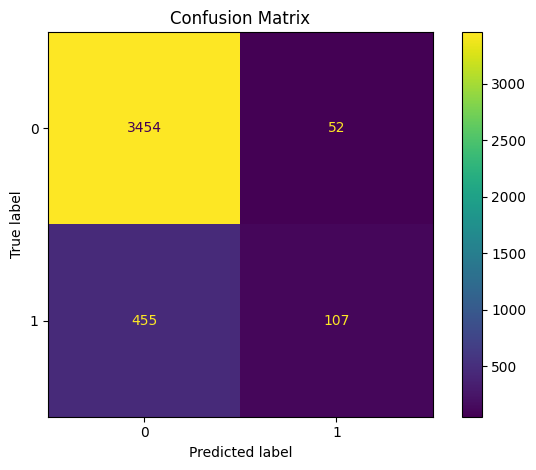

In [109]:
model_hgbc.fit(X_train, y_train)
pred = model_hgbc.predict(X_test)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

[[3422  100]
 [ 416  130]]
              precision    recall  f1-score   support

         0.0       0.89      0.97      0.93      3522
         1.0       0.57      0.24      0.34       546

    accuracy                           0.87      4068
   macro avg       0.73      0.60      0.63      4068
weighted avg       0.85      0.87      0.85      4068



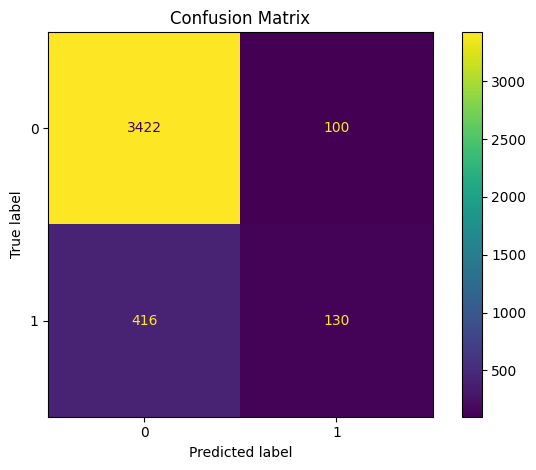

In [97]:


# 2) Preprocess: impute + one-hot for categoricals, impute for numerics
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # use sparse output by default
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_columns),
        ("num", numeric_pipeline, numerical_columns),
    ],
    remainder="passthrough"
)

# 3) Model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"  # avoids warning in many setups
)

# 4) Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

# numeric matrix
cm = confusion_matrix(y_test, pred)
print(cm)

print(classification_report(y_test, pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [98]:
cross_validate(clf, X, y, return_train_score=True)

{'fit_time': array([0.69631481, 0.70266604, 0.74676681, 0.91459417, 0.76059079]),
 'score_time': array([0.01117921, 0.01090503, 0.01076627, 0.01131701, 0.01197624]),
 'test_score': array([0.87066052, 0.87523049, 0.87861094, 0.87185003, 0.87307929]),
 'train_score': array([0.95175169, 0.95144811, 0.95283091, 0.9507567 , 0.9517554 ])}

In [99]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    clf, X, y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
    return_train_score=True
)
scores

{'fit_time': array([0.72076416, 0.71770215, 0.80767322, 0.64734697, 0.66754222]),
 'score_time': array([0.02954698, 0.02942705, 0.02878094, 0.02932715, 0.02884674]),
 'test_accuracy': array([0.87373272, 0.87523049, 0.87000615, 0.88076214, 0.86631838]),
 'train_accuracy': array([0.95098341, 0.9507567 , 0.95106399, 0.95505877, 0.94968119]),
 'test_balanced_accuracy': array([0.60095083, 0.60461535, 0.58955253, 0.61985667, 0.60128912]),
 'train_balanced_accuracy': array([0.82695848, 0.82497414, 0.82839105, 0.84112063, 0.82157364]),
 'test_f1': array([0.32952692, 0.33876221, 0.30082645, 0.37620579, 0.32766615]),
 'train_f1': array([0.78818061, 0.78626209, 0.78928217, 0.80888598, 0.78086316]),
 'test_roc_auc': array([0.7771806 , 0.77935742, 0.76654191, 0.78182816, 0.76698168]),
 'train_roc_auc': array([0.98911207, 0.98789561, 0.98775081, 0.99113388, 0.98957518])}

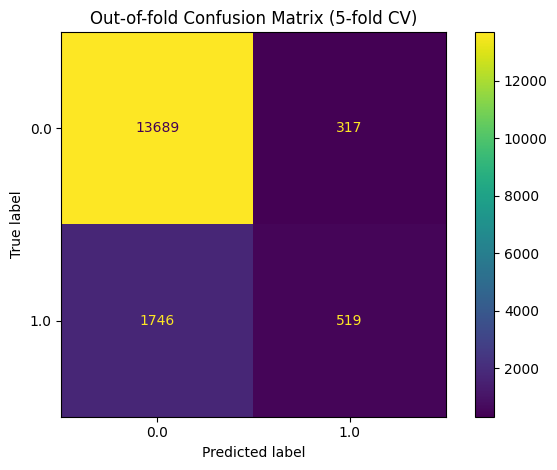

In [100]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_pred = cross_val_predict(clf, X, y, cv=cv, method="predict")

ConfusionMatrixDisplay.from_predictions(y, oof_pred, values_format="d")
plt.title("Out-of-fold Confusion Matrix (5-fold CV)")
plt.tight_layout()
plt.show()

In [74]:
clf.set_params(
    model__max_depth=3,
    model__min_child_weight=10,
    model__subsample=0.8,
    model__colsample_bytree=0.8,
    model__reg_lambda=10.0,
    model__reg_alpha=0.5,
    model__n_estimators=400,
    model__learning_rate=0.05,
)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [101]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score

y = y.astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
best = (-1, None, None)

for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    f1 = f1_score(y, pred)
    if f1 > best[0]:
        best = (f1, t, confusion_matrix(y, pred))

best_f1, best_t, best_cm = best
print("Best F1:", best_f1)
print("Best threshold:", best_t)
print("Confusion matrix at best threshold:\n", best_cm)


Best F1: 0.43842272472435057
Best threshold: 0.19
Confusion matrix at best threshold:
 [[12093  1913]
 [ 1092  1173]]


In [76]:
import optuna

In [77]:
def objective(trial):

    max_depth = trial.suggest_int("max_depth", 2, 20)

    n_estimators = trial.suggest_int("n_estimators", 200, 2000)

    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)


    # 2) Preprocess: impute + one-hot for categoricals, impute for numerics
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))  # use sparse output by default
    ])

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", categorical_pipeline, categorical_columns),
            ("num", numeric_pipeline, numerical_columns),
        ],
        remainder="passthrough"
    )

    # 3) Model
    xgb = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,

        random_state=42,
        n_jobs=-1,
    )

    # 4) Full pipeline
    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", xgb)
    ])

    scores = cross_validate(
        clf,
        X,
        y,
        cv=5,
        scoring="average_precision",
        n_jobs=-1,
    )

    return scores["test_score"].mean()


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.RandomSampler(seed=42),
)

study.optimize(objective, n_trials=100)


print("Best trial:", study.best_trial.value, study.best_trial.params)


[I 2025-11-28 10:56:52,999] A new study created in memory with name: no-name-ad318928-d14c-4847-a1e5-9f1b4a48bb42
[I 2025-11-28 10:56:59,540] Trial 0 finished with value: 0.25328608937470953 and parameters: {'max_depth': 9, 'n_estimators': 1912, 'learning_rate': 0.22227824312530747}. Best is trial 0 with value: 0.25328608937470953.
[I 2025-11-28 10:57:04,042] Trial 1 finished with value: 0.26796289088821457 and parameters: {'max_depth': 13, 'n_estimators': 480, 'learning_rate': 0.055238410897498764}. Best is trial 1 with value: 0.26796289088821457.
[I 2025-11-28 10:57:07,615] Trial 2 finished with value: 0.2516213312317058 and parameters: {'max_depth': 3, 'n_estimators': 1759, 'learning_rate': 0.18432335340553055}. Best is trial 1 with value: 0.26796289088821457.
[I 2025-11-28 10:57:10,842] Trial 3 finished with value: 0.25911217526213765 and parameters: {'max_depth': 15, 'n_estimators': 237, 'learning_rate': 0.29127385712697834}. Best is trial 1 with value: 0.26796289088821457.
[I 202

KeyboardInterrupt: 

In [81]:
# 4) Full pipeline
 # 3) Model
xgb_tuned = XGBClassifier(
    n_estimators=1362,
    learning_rate=0.06136209702804419,
    max_depth=2,

    random_state=42,
    n_jobs=-1,
)

clf_tuned = Pipeline(steps=[
                        ("preprocess", preprocess),
                        ("model", xgb_tuned)
])

In [ ]:
df_test =